In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')



In [5]:
#caricamento dataset
df = pd.read_csv('menstrual_health_dataset.csv')

In [6]:
#formattazione data
df['date'] = pd.to_datetime(df['date'], format='%d-%b-%y')

In [7]:
#analisi preliminare
print('--- struttura dataset ---')
print(df.info())


--- struttura dataset ---
<class 'pandas.DataFrame'>
RangeIndex: 8986 entries, 0 to 8985
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   user_id               8986 non-null   int64         
 1   date                  8986 non-null   datetime64[us]
 2   age                   8986 non-null   int64         
 3   contraceptive_use     8986 non-null   bool          
 4   cycle_index           8948 non-null   float64       
 5   day_in_cycle          8948 non-null   float64       
 6   period_day            8986 non-null   bool          
 7   cycle_length_days     8948 non-null   float64       
 8   period_duration_days  8948 non-null   float64       
 9   sleep_hours           8986 non-null   float64       
 10  stress_level          8986 non-null   int64         
 11  activity_minutes      8986 non-null   int64         
 12  water_intake_l        8986 non-null   float64       
 13  pai

In [8]:
print('--- valori mancanti ---')
print(df.isnull().sum()[df.isnull().sum() > 0].sort_values(ascending=False))

--- valori mancanti ---
fatigue_score           150
mood_score              150
pain_level              150
cycle_length_days        38
day_in_cycle             38
cycle_index              38
period_duration_days     38
dtype: int64


controllo integrità dei dati

In [9]:
#Controllo duplicati 

duplicati = df.duplicated().sum()
print(f'Righe duplicate nel dataset: {duplicati}')

Righe duplicate nel dataset: 0


In [10]:
#controllo record duplicati per lo stesso utente (stesso utente con due o più date uguali)
conflitti_temporali = df.duplicated(subset=['user_id', 'date']).sum()
print(f"Giorni con più record per lo stesso utente: {conflitti_temporali}")

Giorni con più record per lo stesso utente: 0


In [11]:
print("--- controllo continuità ---")
for user, user_data in df.groupby('user_id'):
    user_data = user_data.sort_values('date')
    giorni_attesi = (user_data['date'].max() - user_data['date'].min()).days + 1
    giorni_effettivi = len(user_data)
    
    if giorni_attesi != giorni_effettivi:
        print(f"Utente {user}: Rilevata discontinuità! Attesi {giorni_attesi} gg, presenti {giorni_effettivi} gg.")

--- controllo continuità ---
Utente 6: Rilevata discontinuità! Attesi 180 gg, presenti 173 gg.
Utente 22: Rilevata discontinuità! Attesi 180 gg, presenti 173 gg.


In [12]:
errori_sonno = df[(df['sleep_hours'] < 0) | (df['sleep_hours'] > 24)].shape[0]
errori_acqua = df[(df['water_intake_l'] < 0) | (df['water_intake_l'] > 10)].shape[0]
print(f"\nRecord con ore di sonno impossibili: {errori_sonno}")
print(f"Record con assunzione d'acqua irrealistica: {errori_acqua}")


Record con ore di sonno impossibili: 0
Record con assunzione d'acqua irrealistica: 0


In [13]:
#verifica che ogni utente non cambi lo stato di assunzione della pillola durante i 6 mesi
contraceptive_dynamic_check = df.groupby('user_id')['contraceptive_use'].nunique().reset_index()
contraceptive_dynamic_check.head()

,user_id,contraceptive_use
0,1,1
1,2,1
2,3,1
3,4,1
4,5,1


nessun utente cambia lo stato di assunzione del contraccettivo durante i 6 mesi di tracking


In [14]:
#df di un utente singolo
df_users = df.groupby('user_id').agg({
    'age': 'first',
    'contraceptive_use': 'first',
    'cycle_index': 'nunique' # Quanti cicli completi ha tracciato
}).reset_index()

df_users.head()



,user_id,age,contraceptive_use,cycle_index
0,1,21,False,6
1,2,26,False,7
2,3,25,False,7
3,4,21,False,7
4,5,35,False,7


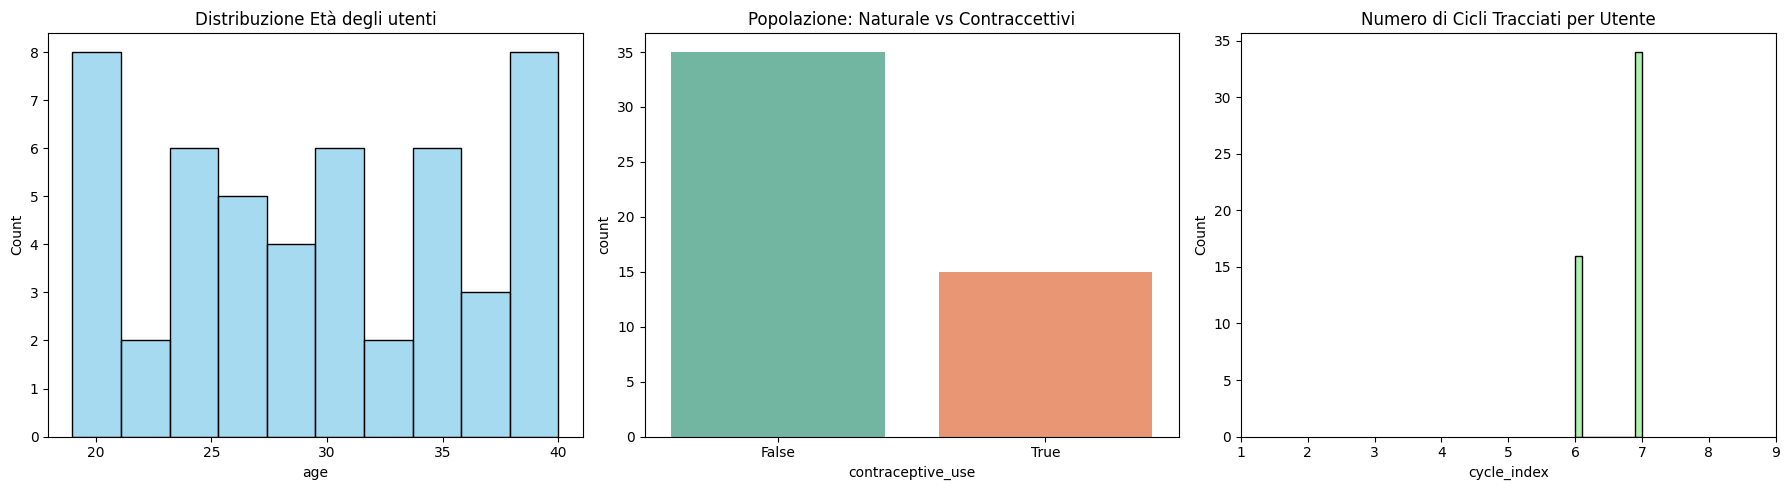

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Distribuzione Età
sns.histplot(data=df_users, x='age', bins=10, ax=axes[0], color='skyblue')
axes[0].set_title('Distribuzione Età degli utenti')

# 2. Uso Contraccettivi
sns.countplot(data=df_users, x='contraceptive_use', ax=axes[1], palette='Set2')
axes[1].set_title('Popolazione: Naturale vs Contraccettivi')

# 3. Quanti cicli sono stati tracciati per utente?
sns.histplot(data=df_users, x='cycle_index', bins=10, ax=axes[2], color='lightgreen')
axes[2].set_title('Numero di Cicli Tracciati per Utente')
axes[2].set_xticks(range(1, 10))

plt.tight_layout()
plt.show()

Data cleaning:


per fatigue_score, mood_score e pain_level si decide di riempire gli NA con la mediana dell'utente specifico, evitando di inquinare i dati di un utente con quelli di un altro.

In [16]:

# Imputazione dei sintomi con la mediana dello specifico utente
symptom_cols = ['fatigue_score', 'mood_score', 'pain_level']
for col in symptom_cols:
    df[col] = df.groupby('user_id')[col].transform(lambda x: x.fillna(x.median()))
# Controllo se ci sono ancora NA (es. se un utente ha TUTTI i record di un sintomo vuoti)
print("Valori mancanti dopo l'imputazione dei sintomi:")
print(df[symptom_cols].isnull().sum())

Valori mancanti dopo l'imputazione dei sintomi:
fatigue_score    0
mood_score       0
pain_level       0
dtype: int64


I valori mancanti relativi alle variabili strutturali del ciclo (cycle_length_days, day_in_cycle, cycle_index, period_duration_days) sono imputabili esclusivamente agli utenti 6 e 22, i quali presentano una lacuna nel tracciamento pari a circa una settimana. La somma dei giorni classificati come NaN, unita ai 7 giorni di mancato tracciamento, corrisponde approssimativamente alla durata di un ciclo intero. Poiché la ricostruzione artificiale di un intero ciclo per questi due utenti produrrebbe dati largamente approssimativi e imprecisi (rischiando di inserire bias nei successivi modelli), si opta per la rimozione diretta delle righe contenenti tali NaN. Di conseguenza, gli utenti 6 e 22 figureranno con un ciclo in meno, garantendo però la totale affidabilità e coerenza del dataset.


In [17]:
# Rimuovo le righe dove cycle_index è NaN
df = df.dropna(subset=['cycle_index'])

# Verifica
print('--- valori mancanti ---')
print(df.isnull().sum()[df.isnull().sum() > 0].sort_values(ascending=False))

#NA gestiti

--- valori mancanti ---
Series([], dtype: int64)


In [18]:
# Arrotonda la colonna delle ore di sonno a 1 cifra decimale
df['sleep_hours'] = df['sleep_hours'].round(1)

df['water_intake_l'] = df['water_intake_l'].round(1)



statistiche dezcrittive:

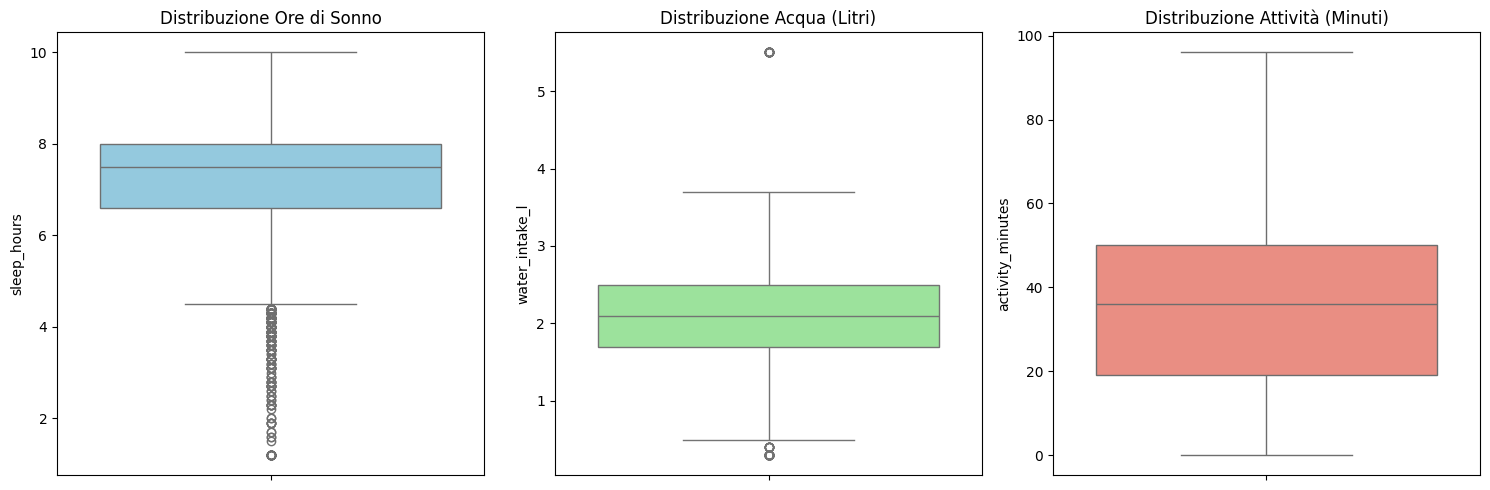

In [19]:
#dentificazione outlier

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(y=df['sleep_hours'], ax=axes[0], color='skyblue')
axes[0].set_title('Distribuzione Ore di Sonno')

sns.boxplot(y=df['water_intake_l'], ax=axes[1], color='lightgreen')
axes[1].set_title('Distribuzione Acqua (Litri)')

sns.boxplot(y=df['activity_minutes'], ax=axes[2], color='salmon')
axes[2].set_title('Distribuzione Attività (Minuti)')

plt.tight_layout()
plt.show()


In [20]:
print("--- Statistiche Demografiche (Livello Utente) ---")
df_user = df.groupby('user_id')['age'].first().to_frame()
display(df_user.describe().round(2))

--- Statistiche Demografiche (Livello Utente) ---


,age
count,50.00
mean,29.56
std,6.49
min,19.00
25%,24.25
50%,29.50
75%,35.00
max,40.00


In [21]:
print("\n--- Statistiche del Ciclo Biologico ---")
# Prendiamo il primo valore di lunghezza per ogni combinazione Utente-Ciclo
df_cycle = df.groupby(['user_id', 'cycle_index'])[['cycle_length_days', 'period_duration_days']].first()
display(df_cycle.describe().round(2))


--- Statistiche del Ciclo Biologico ---


,cycle_length_days,period_duration_days
count,334.00,334.00
mean,28.66,5.46
std,3.60,1.12
min,19.00,4.00
25%,27.00,4.00
50%,28.00,5.00
75%,30.00,6.00
max,42.00,7.00


In [22]:
print("\n--- Statistiche Giornaliere (Stile di vita e Sintomi) ---")
daily_cols = [
    'sleep_hours', 'stress_level', 'activity_minutes', 
    'water_intake_l', 'pain_level', 'mood_score', 'fatigue_score'
]
display(df[daily_cols].describe().round(2))


--- Statistiche Giornaliere (Stile di vita e Sintomi) ---


,sleep_hours,stress_level,activity_minutes,water_intake_l,pain_level,mood_score,fatigue_score
count,8948.00,8948.00,8948.00,8948.00,8948.00,8948.00,8948.00
mean,7.16,2.62,35.12,2.06,1.61,3.52,2.95
std,1.23,1.16,19.37,0.60,2.64,0.84,2.56
min,1.20,1.00,0.00,0.30,0.00,1.00,0.00
25%,6.60,2.00,19.00,1.70,0.00,3.00,1.00
50%,7.50,2.00,36.00,2.10,0.00,4.00,3.00
75%,8.00,3.00,50.00,2.50,3.00,4.00,5.00
max,10.00,5.00,96.00,5.50,10.00,4.00,10.00


HEATMAP

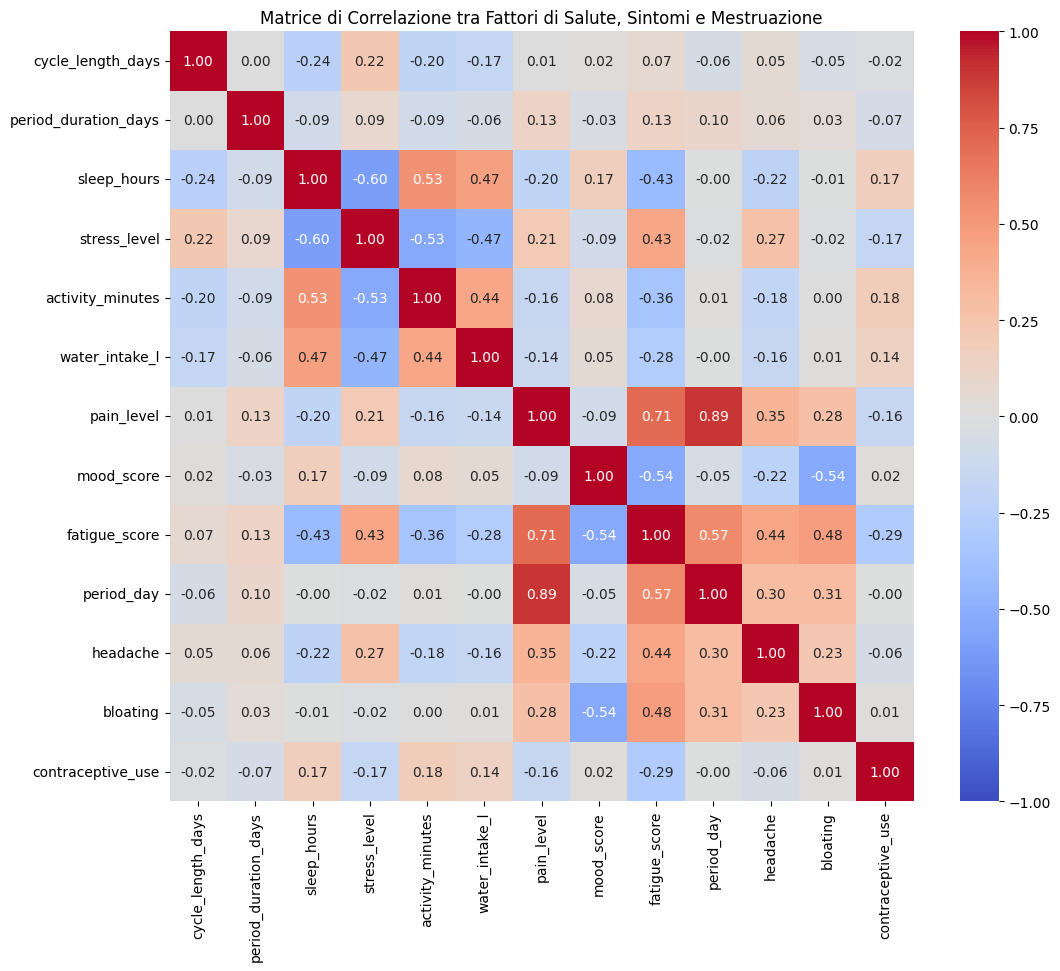

In [23]:
# Seleziono le colonne numeriche e booleane
cols_to_correlate = [
    'cycle_length_days', 'period_duration_days', 'sleep_hours', 
    'stress_level', 'activity_minutes', 'water_intake_l', 
    'pain_level', 'mood_score', 'fatigue_score',
    'period_day', 'headache', 'bloating', 'contraceptive_use' 
]

# Pandas convertirà in automatico i True in 1 e i False in 0 per calcolare la correlazione
corr_matrix = df[cols_to_correlate].corr()

plt.figure(figsize=(12, 10)) 
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title('Matrice di Correlazione tra Fattori di Salute, Sintomi e Mestruazione')
plt.show()


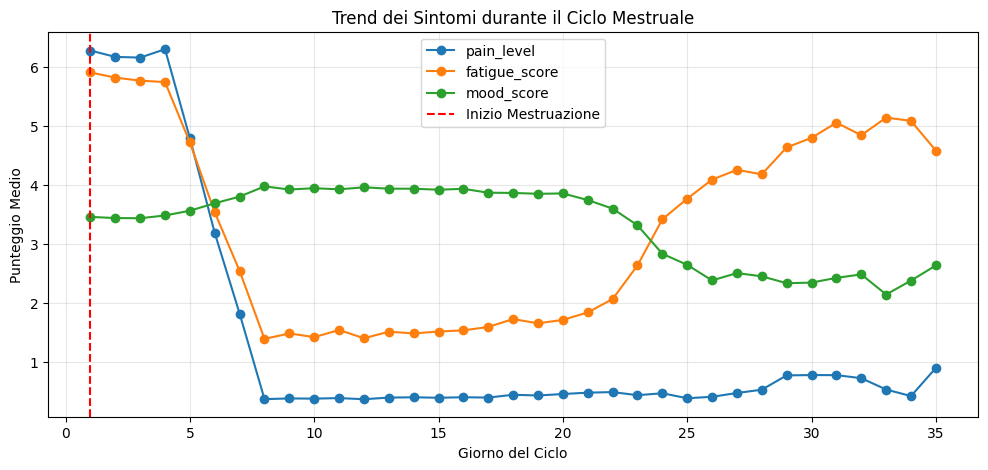

In [24]:
# Calcolo la media dei sintomi per ogni giorno del ciclo
symptoms_by_day = df.groupby('day_in_cycle')[['pain_level', 'fatigue_score', 'mood_score']].mean()

# Plot limitato ai primi 35 giorni per evitare rumore alla fine di cicli lunghissimi
symptoms_by_day.head(35).plot(figsize=(12, 5), marker='o')
plt.title('Trend dei Sintomi durante il Ciclo Mestruale')
plt.xlabel('Giorno del Ciclo')
plt.ylabel('Punteggio Medio')
plt.grid(True, alpha=0.3)
plt.axvline(x=1, color='r', linestyle='--', label='Inizio Mestruazione')
plt.legend()
plt.show()


In [25]:
# Calcoliamo la variabilità del ciclo per ogni utente (deviazione standard)
user_profiles = df.groupby('user_id').agg({
    'cycle_length_days': ['mean', 'std'],
    'pain_level': 'mean',
    'stress_level': 'mean'
})
user_profiles.columns = ['Avg_Cycle_Length', 'Cycle_Std', 'Avg_Pain', 'Avg_Stress']

# Vediamo chi sono gli utenti con i cicli più irregolari
print("Utenti con i cicli più irregolari (alta deviazione standard):")
print(user_profiles.sort_values(by='Cycle_Std', ascending=False).head())


Utenti con i cicli più irregolari (alta deviazione standard):
         Avg_Cycle_Length  Cycle_Std  Avg_Pain  Avg_Stress
user_id                                                   
49              31.300000   8.051441  1.244444    3.927778
33              30.311111   6.782568  2.066667    3.983333
40              29.738889   6.448216  1.466667    1.933333
37              29.855556   6.171770  1.433333    2.144444
20              30.977778   6.138946  0.866667    2.000000


Analisi di pillola vs non pillola


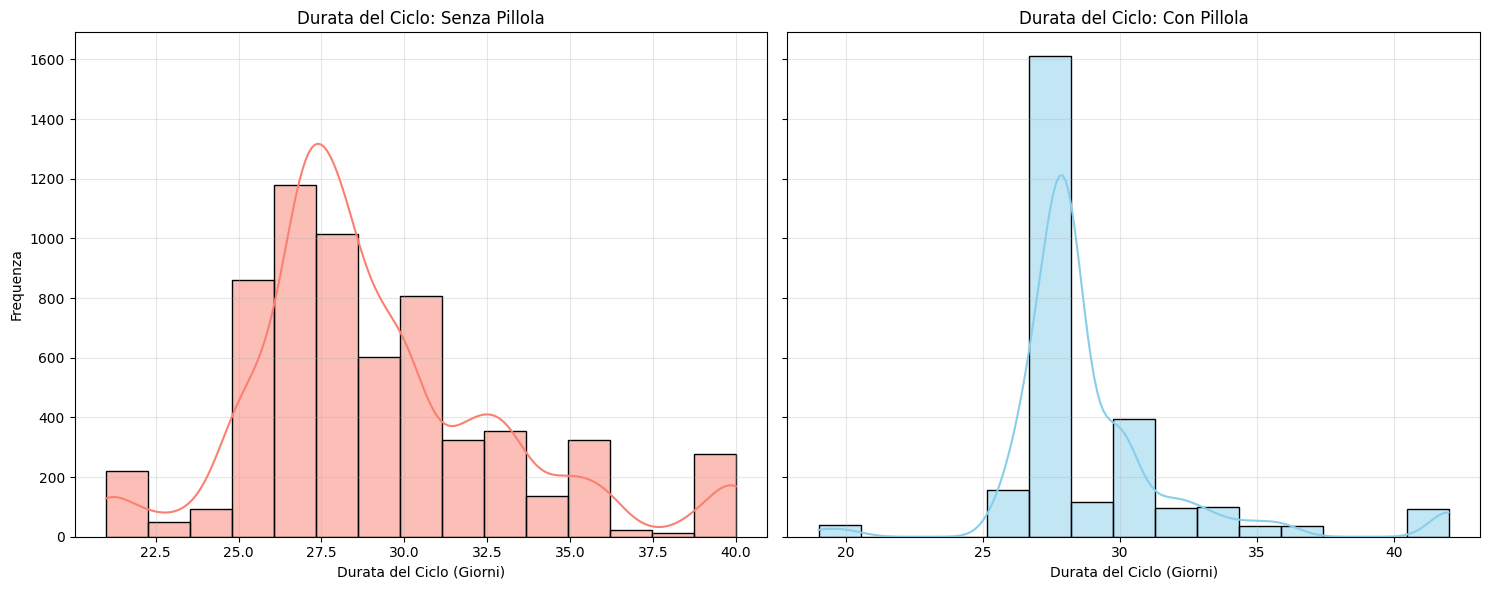

In [26]:
# Creiamo due grafici affiancati (1 riga, 2 colonne)
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

# Grafico 1: Chi NON prende la pillola
sns.histplot(data=df[df['contraceptive_use'] == False], x='cycle_length_days', 
             kde=True, bins=15, ax=axes[0], color='salmon')
axes[0].set_title('Durata del Ciclo: Senza Pillola')
axes[0].set_xlabel('Durata del Ciclo (Giorni)')
axes[0].set_ylabel('Frequenza')
axes[0].grid(True, alpha=0.3) # Aggiunta griglia

# Grafico 2: Chi PRENDE la pillola
sns.histplot(data=df[df['contraceptive_use'] == True], x='cycle_length_days', 
             kde=True, bins=15, ax=axes[1], color='skyblue')
axes[1].set_title('Durata del Ciclo: Con Pillola')
axes[1].set_xlabel('Durata del Ciclo (Giorni)')
axes[1].grid(True, alpha=0.3) # Aggiunta griglia

plt.tight_layout()
plt.show()


In [35]:
# 2. Dividiamo il dataset nei due macro-gruppi di partenza
gruppo_contraccettivi = df[df['contraceptive_use'] == True]
gruppo_naturali = df[df['contraceptive_use'] == False]

print("--- 1. IPOTESI: STABILITÀ DELLA DURATA DEL CICLO ---")
# Estraiamo la durata di ogni ciclo unico per utente nei due gruppi
cicli_contraccettivi = gruppo_contraccettivi.groupby(['user_id', 'cycle_index'])['cycle_length_days'].first()
cicli_naturali = gruppo_naturali.groupby(['user_id', 'cycle_index'])['cycle_length_days'].first()

print(f"Deviazione Standard (Contraccettivi): {cicli_contraccettivi.std():.2f} giorni")
print(f"Deviazione Standard (Cicli Naturali): {cicli_naturali.std():.2f} giorni")
print(f"Media Durata Ciclo (Contraccettivi): {cicli_contraccettivi.mean():.2f} giorni")
print(f"Media Durata Ciclo (Cicli Naturali): {cicli_naturali.mean():.2f} giorni")
print("\n")

print("--- 2. IPOTESI: ABBATTIMENTO DEL DOLORE MEDIO ---")
print(f"Dolore Medio (Contraccettivi): {gruppo_contraccettivi['pain_level'].mean():.2f} / 10")
print(f"Dolore Medio (Cicli Naturali): {gruppo_naturali['pain_level'].mean():.2f} / 10")
print("\n")

print("--- 3. IPOTESI: STABILITÀ DEI SINTOMI NEL MESE ---")
# Calcoliamo la variabilità del dolore lungo i diversi giorni del ciclo (day_in_cycle)
# Se il farmaco stabilizza i sintomi, la deviazione standard del dolore tra i vari giorni del mese dovrebbe essere molto bassa.
var_dolore_giorni_contr = gruppo_contraccettivi.groupby('day_in_cycle')['pain_level'].mean().std()
var_dolore_giorni_nat = gruppo_naturali.groupby('day_in_cycle')['pain_level'].mean().std()

print(f"Variabilità del dolore tra i giorni del mese (Contraccettivi): {var_dolore_giorni_contr:.2f}")
print(f"Variabilità del dolore tra i giorni del mese (Cicli Naturali): {var_dolore_giorni_nat:.2f}")

--- 1. IPOTESI: STABILITÀ DELLA DURATA DEL CICLO ---
Deviazione Standard (Contraccettivi): 3.23 giorni
Deviazione Standard (Cicli Naturali): 3.76 giorni
Media Durata Ciclo (Contraccettivi): 28.71 giorni
Media Durata Ciclo (Cicli Naturali): 28.63 giorni


--- 2. IPOTESI: ABBATTIMENTO DEL DOLORE MEDIO ---
Dolore Medio (Contraccettivi): 0.96 / 10
Dolore Medio (Cicli Naturali): 1.89 / 10


--- 3. IPOTESI: STABILITÀ DEI SINTOMI NEL MESE ---
Variabilità del dolore tra i giorni del mese (Contraccettivi): 1.47
Variabilità del dolore tra i giorni del mese (Cicli Naturali): 2.06


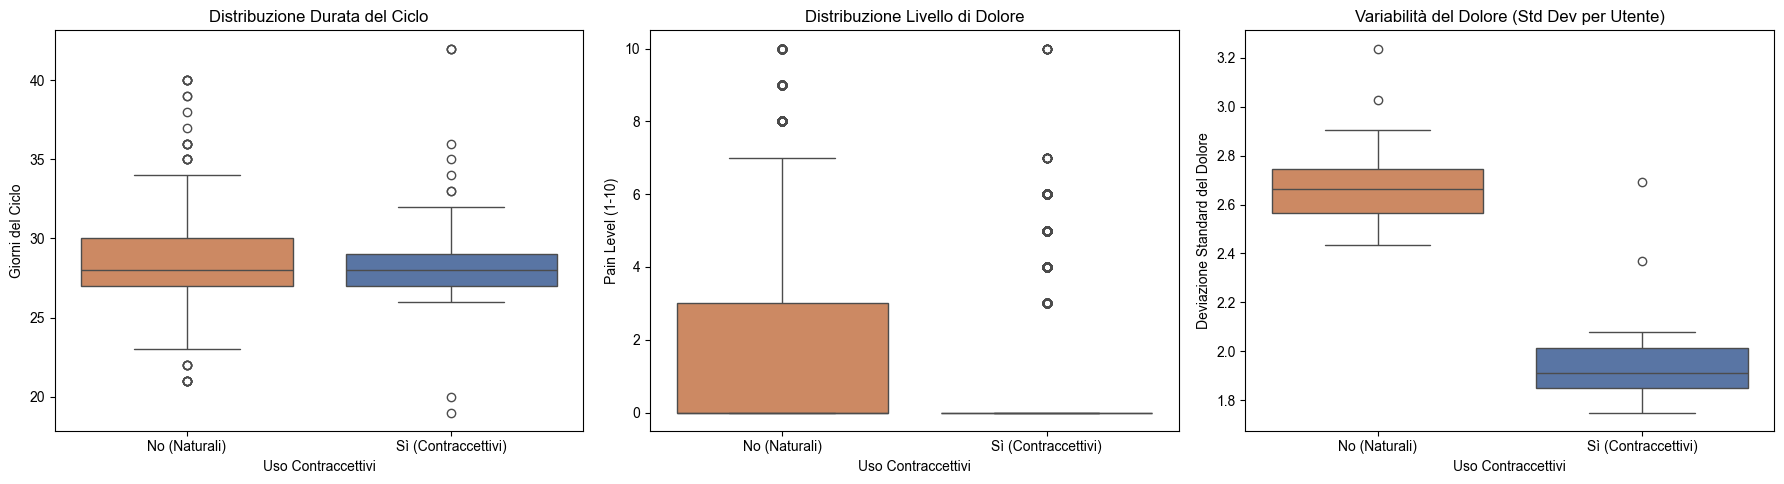

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepariamo i dati per la durata del ciclo (aggregati per ciclo unico)
cicli_df = df.groupby(['user_id', 'cycle_index', 'contraceptive_use'])['cycle_length_days'].first().reset_index()

# 2. Convertiamo i booleani in stringhe chiare sia per il DF del ciclo che per quello generale
# Questo previene qualsiasi errore di mappatura della palette di Seaborn
cicli_df['contraceptive_str'] = cicli_df['contraceptive_use'].map({True: 'Sì (Contraccettivi)', False: 'No (Naturali)'})
df['contraceptive_str'] = df['contraceptive_use'].map({True: 'Sì (Contraccettivi)', False: 'No (Naturali)'})

# Calcoliamo la deviazione standard del dolore di ogni singolo utente

var_utente = df.groupby(['user_id', 'contraceptive_str'])['pain_level'].std().reset_index()

# Configurazione della figura (3 grafici affiancati)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.set_theme(style="whitegrid")

# Definizione di una palette fissa basata sulle nuove stringhe
color_palette = {'Sì (Contraccettivi)': '#4C72B0', 'No (Naturali)': '#DD8452'}

# --- BOXPLOT 1: Distribuzione Durata del Ciclo ---
sns.boxplot(
    data=cicli_df, 
    x='contraceptive_str', 
    y='cycle_length_days', 
    ax=axes[0],
    palette=color_palette
)
axes[0].set_title('Distribuzione Durata del Ciclo')
axes[0].set_xlabel('Uso Contraccettivi')
axes[0].set_ylabel('Giorni del Ciclo')

# --- BOXPLOT 2: Distribuzione Livello di Dolore ---
sns.boxplot(
    data=df, 
    x='contraceptive_str', 
    y='pain_level', 
    ax=axes[1],
    palette=color_palette
)
axes[1].set_title('Distribuzione Livello di Dolore')
axes[1].set_xlabel('Uso Contraccettivi')
axes[1].set_ylabel('Pain Level (1-10)')

# --- BOXPLOT 3: Stabilità del Dolore (Variabilità per Utente) ---
sns.boxplot(
    data=var_utente, 
    x='contraceptive_str', 
    y='pain_level', 
    ax=axes[2],
    palette=color_palette
)
axes[2].set_title('Variabilità del Dolore (Std Dev per Utente)')
axes[2].set_xlabel('Uso Contraccettivi')
axes[2].set_ylabel('Deviazione Standard del Dolore')

# Ottimizza lo spazio tra i grafici e mostra
plt.tight_layout()
plt.show()

l'abbattimento del dolore esiste. chi prende pillola ha un dolore medio pari alla metà dell'altro gruppo. c'è anche una differenza tra i due gruppi riguardo la variabilità del dolore. chi prende la pillola ha un dolore più stabile e basso.


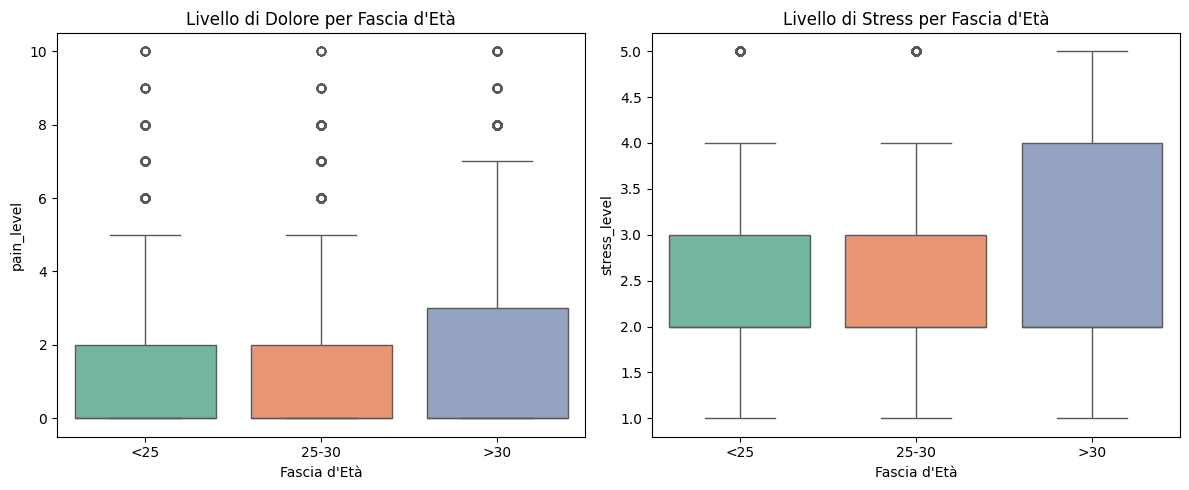

In [27]:
# Creiamo la colonna age_group se non l'hai già creata
df['age_group'] = pd.cut(df['age'], bins=[0, 24, 30, 100], labels=['<25', '25-30', '>30'])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Dolore per età
sns.boxplot(data=df, x='age_group', y='pain_level', ax=axes[0], palette='Set2')
axes[0].set_title('Livello di Dolore per Fascia d\'Età')
axes[0].set_xlabel('Fascia d\'Età')

# Stress per età
sns.boxplot(data=df, x='age_group', y='stress_level', ax=axes[1], palette='Set2')
axes[1].set_title('Livello di Stress per Fascia d\'Età')
axes[1].set_xlabel('Fascia d\'Età')

plt.tight_layout()
plt.show()


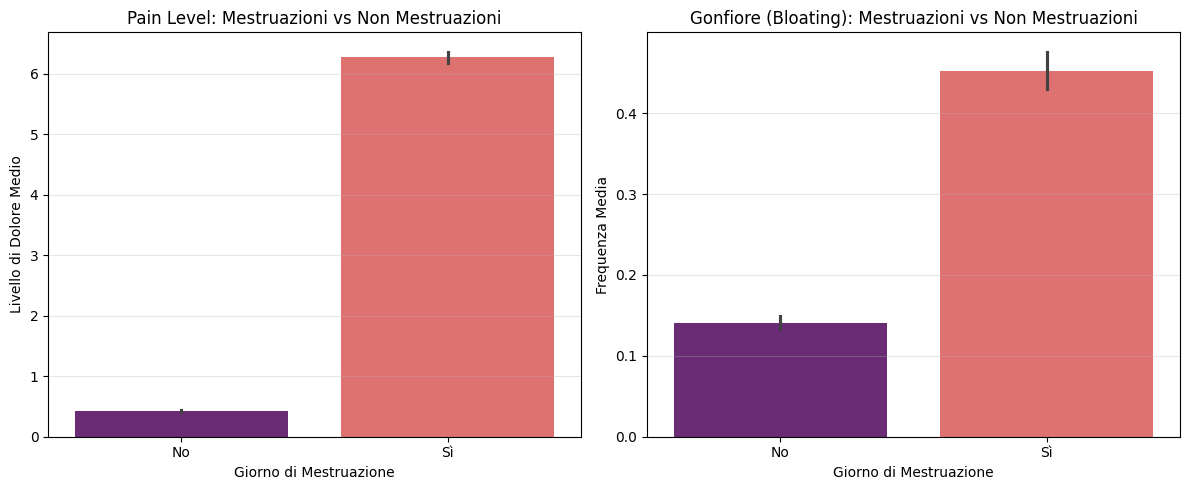

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Grafico 1: Pain Level (Dolore)
sns.barplot(data=df, x='period_day', y='pain_level', ax=axes[0], palette='magma')
axes[0].set_title('Pain Level: Mestruazioni vs Non Mestruazioni')
axes[0].set_xlabel('Giorno di Mestruazione')
axes[0].set_ylabel('Livello di Dolore Medio')
axes[0].set_xticklabels(['No', 'Sì'])
axes[0].grid(axis='y', alpha=0.3)

# Grafico 2: Bloating (Gonfiore)
sns.barplot(data=df, x='period_day', y='bloating', ax=axes[1], palette='magma')
axes[1].set_title('Gonfiore (Bloating): Mestruazioni vs Non Mestruazioni')
axes[1].set_xlabel('Giorno di Mestruazione')
axes[1].set_ylabel('Frequenza Media')
axes[1].set_xticklabels(['No', 'Sì'])
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


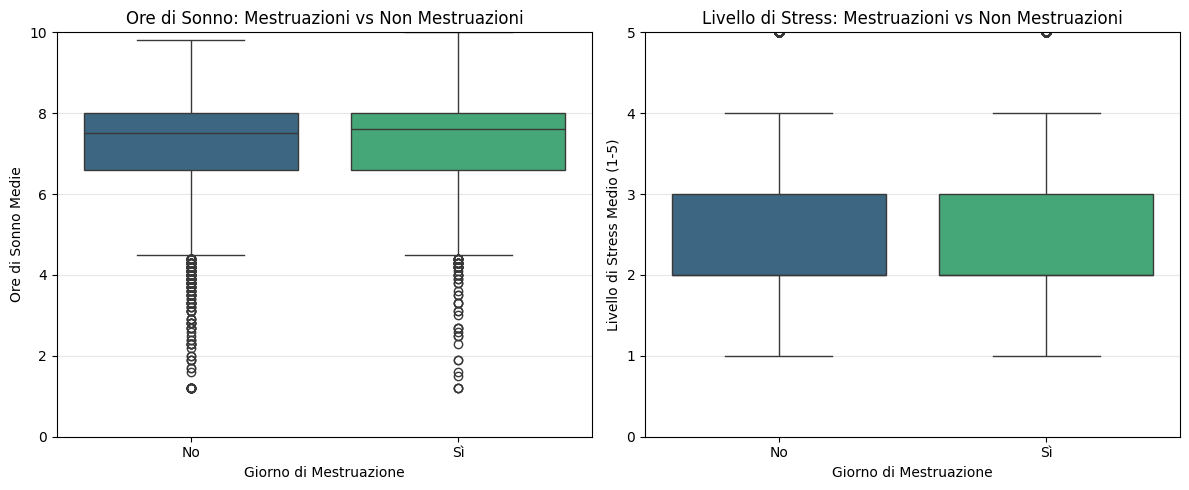

In [ ]:
#influenza del ciclo sulle ore di sonno e sullo stress medio 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Grafico 1: Ore di Sonno
sns.boxplot(data=df, x='period_day', y='sleep_hours', ax=axes[0], palette='viridis')
axes[0].set_title('Ore di Sonno: Mestruazioni vs Non Mestruazioni')
axes[0].set_xlabel('Giorno di Mestruazione')
axes[0].set_ylabel('Ore di Sonno Medie')
axes[0].set_xticklabels(['No', 'Sì'])

# Fissiamo l'asse Y
axes[0].set_ylim(0, 10) 
axes[0].grid(axis='y', alpha=0.3)

# Grafico 2: Livello di Stress
sns.boxplot(data=df, x='period_day', y='stress_level', ax=axes[1], palette='viridis')
axes[1].set_title('Livello di Stress: Mestruazioni vs Non Mestruazioni')
axes[1].set_xlabel('Giorno di Mestruazione')
axes[1].set_ylabel('Livello di Stress Medio (1-5)')
axes[1].set_xticklabels(['No', 'Sì'])

# Fissiamo l'asse Y per lo stress (da 0 a 5)
axes[1].set_ylim(0, 5) 
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


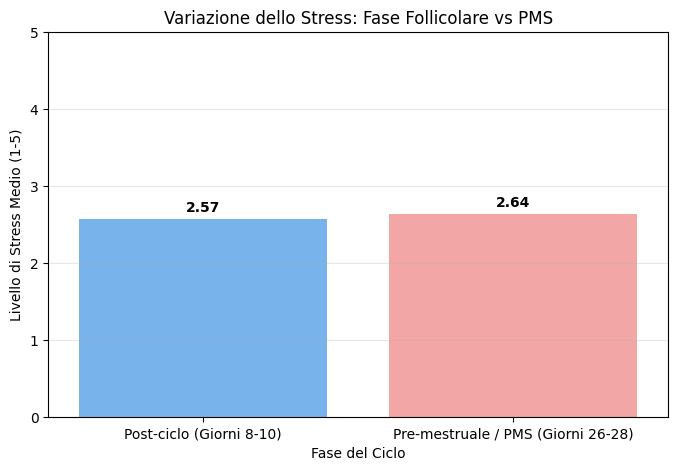

In [32]:
# 1. Filtriamo i giorni appena prima del ciclo (es. giorni 26, 27, 28)
pms_days = df[df['day_in_cycle'].isin([26, 27, 28])]['stress_level'].mean()

# 2. Filtriamo giorni "tranquilli" (es. subito dopo il ciclo, giorni 8, 9, 10)
follicular_days = df[df['day_in_cycle'].isin([8, 9, 10])]['stress_level'].mean()

# 3. Creiamo un DataFrame temporaneo per il grafico
stress_data = pd.DataFrame({
    'Fase del Ciclo': ['Post-ciclo (Giorni 8-10)', 'Pre-mestruale / PMS (Giorni 26-28)'],
    'Livello Medio di Stress': [follicular_days, pms_days]
})

# 4. Creiamo il grafico
plt.figure(figsize=(8, 5))
sns.barplot(data=stress_data, x='Fase del Ciclo', y='Livello Medio di Stress', palette=['#66b3ff', '#ff9999'])
plt.title('Variazione dello Stress: Fase Follicolare vs PMS')
plt.ylabel('Livello di Stress Medio (1-5)')
plt.ylim(0, 5) # Lo stress ha un massimo di 5, quindi limitiamo l'asse
plt.grid(axis='y', alpha=0.3)

# Aggiungiamo i valori esatti sopra le barre
for index, value in enumerate(stress_data['Livello Medio di Stress']):
    plt.text(index, value + 0.1, f'{value:.2f}', ha='center', fontweight='bold')

plt.show()


L'analisi macro non ha mostrato differenze nello stress medio durante i giorni di sanguinamento. Abbiamo ipotizzato che ciò sia dovuto alla soggettività dei sintomi e al picco di stress tipico della fase pre-mestruale, che veniva diluito nella media dei giorni non-mestruali.
non c'è neanche differenza nelle ore di sonno. questo può essere dovuto alla stanchezza maggiore nelle giornate di ciclo, che portano gi utenti a dormire di più durante la giornata
